In [20]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
import torch

X shape: (2000, 2)
First 5 X:
 [[ 1.7765071   0.19275202]
 [ 0.39780872  0.93039011]
 [ 0.49530794 -0.31832132]
 [-0.94894379  0.16301974]
 [ 0.48495693 -0.33816023]]
Mean of X: [0.49921708 0.2507061 ]
Std of X: [0.87202523 0.50447609]


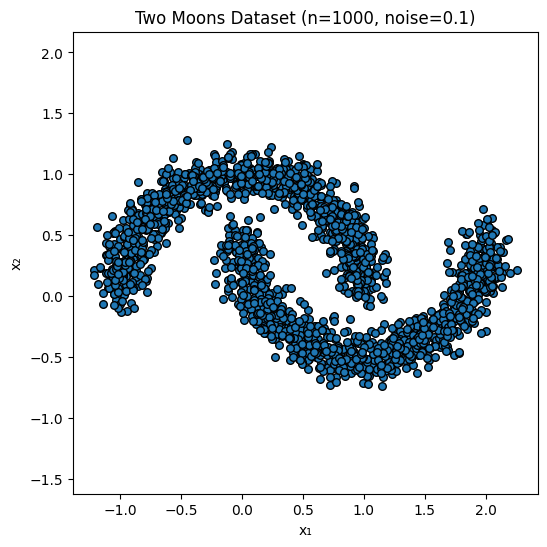

In [21]:
#  Generate data
X, _ = make_moons(n_samples=2000, noise=0.1, random_state=42)
# Inspect shapes and first few rows
print("X shape:", X.shape)    
print("First 5 X:\n", X[:5])
print("Mean of X:", X.mean(axis=0))
print("Std of X:", X.std(axis=0))


plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], edgecolor='k', s=30)
plt.title("Two Moons Dataset (n=1000, noise=0.1)")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.axis("equal")
plt.show()

## Sanity Check: 
Identity of forward and inverse pass is established:

In [22]:
from affine_coupling import AffineCoupling
from affine_coupling import NormalizingFlow

with torch.no_grad():
    ac = AffineCoupling(size=2, d=1, hidden_size=64) 
    ac.test_identity(tolerance=1e-6)

    nf = NormalizingFlow(input_dim=2, num_layers=4, hidden_size=64)
    nf.test_identity(tolerance=1e-6)

Min: -1.4901161193847656e-08, Max: 0.0
Min: -7.450580596923828e-09, Max: 5.960464477539063e-08


## Training the Normalizing Flow
Batch Size: 64
Learning Rate: 0.001
Epochs: 100
Optimizer: AdamW
- $\beta_1$: 0.9
- $\beta_2$: 0.999
- Weight decay: 0.01

To get a better understanding of the model's reconstructive capabilities, we calculate the directed Hausdorff-Distance (Taha and Hanbury, 2015) between the generated samples and the original point-cloud. To better understand the performance, we center the reconstruction to standard deviation and mean of original distribution.

Config file not found: config.yaml
Epoch 1, Loss: 166.8026
Hausdorff distance: 1.7212
Epoch 2, Loss: 165.7241
Hausdorff distance: 1.5119
Epoch 3, Loss: 153.9429
Hausdorff distance: 1.0816
Epoch 4, Loss: 147.4421
Hausdorff distance: 1.0924
Epoch 5, Loss: 140.8285
Hausdorff distance: 1.3376
Epoch 6, Loss: 141.6214
Hausdorff distance: 1.5970
Epoch 7, Loss: 149.1473
Hausdorff distance: 1.7174
Epoch 8, Loss: 147.1791
Hausdorff distance: 1.3632
Epoch 9, Loss: 135.5249
Hausdorff distance: 1.9868
Epoch 10, Loss: 142.9519
Hausdorff distance: 1.6757
Epoch 11, Loss: 134.9203
Hausdorff distance: 1.6374
Epoch 12, Loss: 136.0727
Hausdorff distance: 1.6149
Epoch 13, Loss: 138.5748
Hausdorff distance: 1.3107
Epoch 14, Loss: 118.4363
Hausdorff distance: 1.6555
Epoch 15, Loss: 127.4404
Hausdorff distance: 1.1277
Epoch 16, Loss: 127.3460
Hausdorff distance: 1.5615
Epoch 17, Loss: 124.7515
Hausdorff distance: 0.7917
Epoch 18, Loss: 115.3729
Hausdorff distance: 1.9756
Epoch 19, Loss: 121.0653
Hausdorff dis

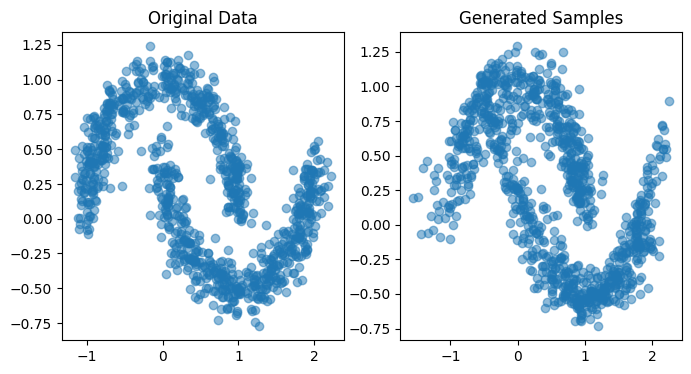

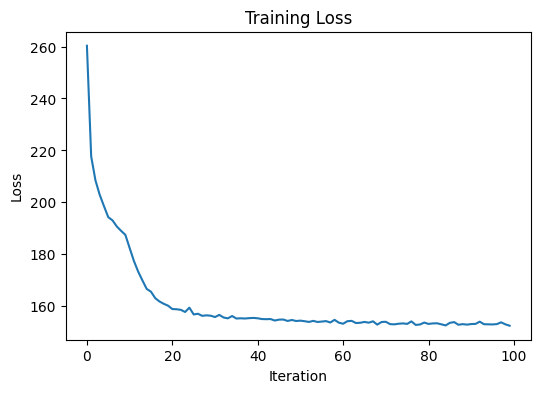

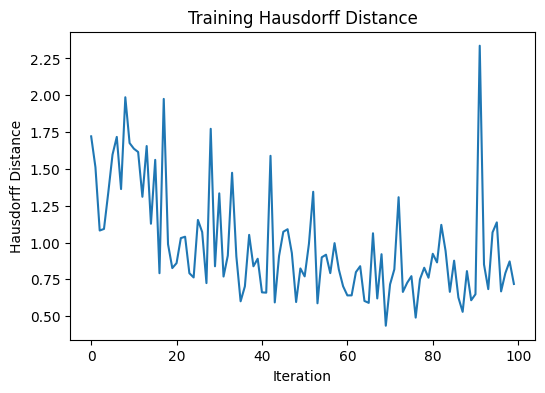

In [23]:
import torch.utils.data as data
from affine_coupling import NormalizingFlow
from config import Config
from sklearn.datasets import make_moons
from train import train_loop

config = Config('config.yaml')

np.random.seed(6)
torch.manual_seed(6)


X, _ = make_moons(n_samples=config.samples, noise=0.1)
x_tensor = torch.tensor(X, dtype=torch.float32)
dataset = data.TensorDataset(x_tensor)
dataloader = data.DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


## Alternative Masks
The default masks the first dimension. Here, we switch the dimension, and leave the mask altogether. 

Epoch 1, Loss: 166.8026
Hausdorff distance: 1.7212
Epoch 2, Loss: 165.7241
Hausdorff distance: 1.5119
Epoch 3, Loss: 153.9429
Hausdorff distance: 1.0816
Epoch 4, Loss: 147.4421
Hausdorff distance: 1.0924
Epoch 5, Loss: 140.8285
Hausdorff distance: 1.3376
Epoch 6, Loss: 141.6214
Hausdorff distance: 1.5970
Epoch 7, Loss: 149.1473
Hausdorff distance: 1.7174
Epoch 8, Loss: 147.1791
Hausdorff distance: 1.3632
Epoch 9, Loss: 135.5249
Hausdorff distance: 1.9868
Epoch 10, Loss: 142.9519
Hausdorff distance: 1.6757
Epoch 11, Loss: 134.9203
Hausdorff distance: 1.6374
Epoch 12, Loss: 136.0727
Hausdorff distance: 1.6149
Epoch 13, Loss: 138.5748
Hausdorff distance: 1.3107
Epoch 14, Loss: 118.4363
Hausdorff distance: 1.6555
Epoch 15, Loss: 127.4404
Hausdorff distance: 1.1277
Epoch 16, Loss: 127.3460
Hausdorff distance: 1.5615
Epoch 17, Loss: 124.7515
Hausdorff distance: 0.7917
Epoch 18, Loss: 115.3729
Hausdorff distance: 1.9756
Epoch 19, Loss: 121.0653
Hausdorff distance: 0.9887
Epoch 20, Loss: 106.0

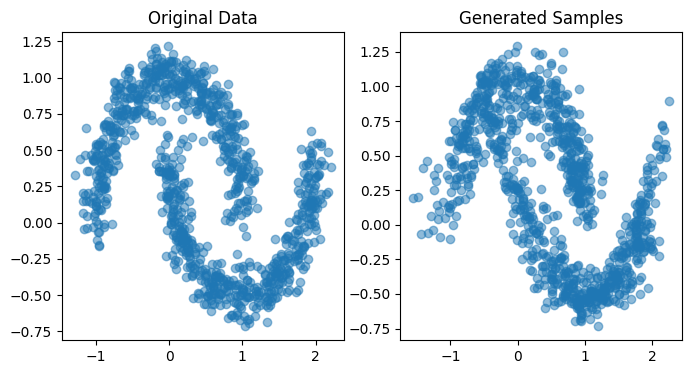

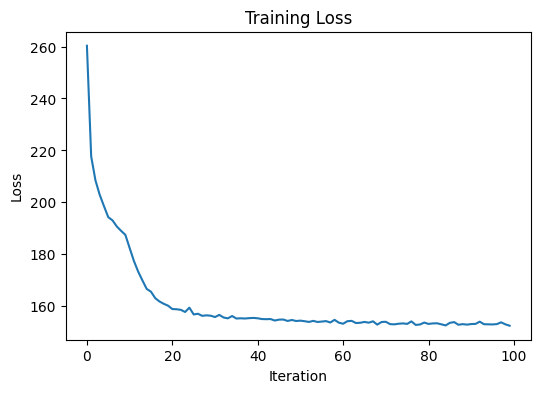

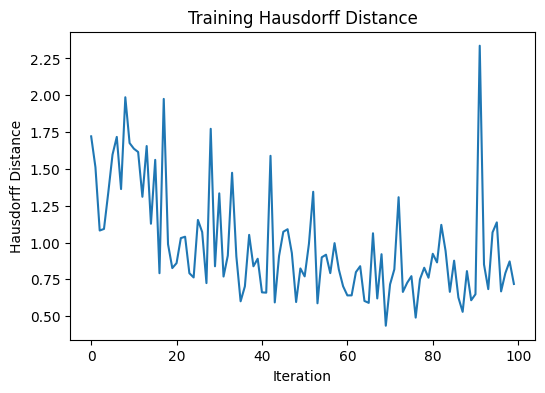

In [24]:
mask = torch.zeros(2)
mask[0] = 1.

np.random.seed(6)
torch.manual_seed(6)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


No mask:

Epoch 1, Loss: 237.8686
Hausdorff distance: 1.5925
Epoch 2, Loss: 237.2516
Hausdorff distance: 1.3027
Epoch 3, Loss: 249.7331
Hausdorff distance: 1.5636
Epoch 4, Loss: 244.0179
Hausdorff distance: 1.4347
Epoch 5, Loss: 247.2433
Hausdorff distance: 1.2460
Epoch 6, Loss: 237.0797
Hausdorff distance: 1.4639
Epoch 7, Loss: 245.7479
Hausdorff distance: 1.4185
Epoch 8, Loss: 229.0258
Hausdorff distance: 1.2936
Epoch 9, Loss: 237.0363
Hausdorff distance: 1.2438
Epoch 10, Loss: 249.2239
Hausdorff distance: 1.1319
Epoch 11, Loss: 241.4623
Hausdorff distance: 1.7416
Epoch 12, Loss: 237.3918
Hausdorff distance: 1.2050
Epoch 13, Loss: 233.7599
Hausdorff distance: 1.3802
Epoch 14, Loss: 241.7231
Hausdorff distance: 1.2970
Epoch 15, Loss: 236.6692
Hausdorff distance: 1.1341
Epoch 16, Loss: 238.0082
Hausdorff distance: 1.7000
Epoch 17, Loss: 244.1842
Hausdorff distance: 1.4571
Epoch 18, Loss: 227.9937
Hausdorff distance: 1.4988
Epoch 19, Loss: 241.3372
Hausdorff distance: 1.3910
Epoch 20, Loss: 237.6

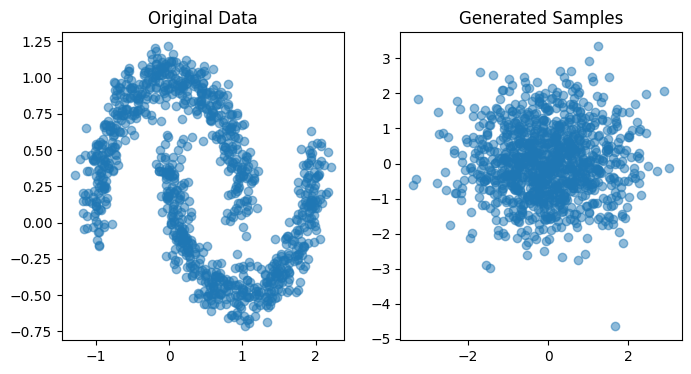

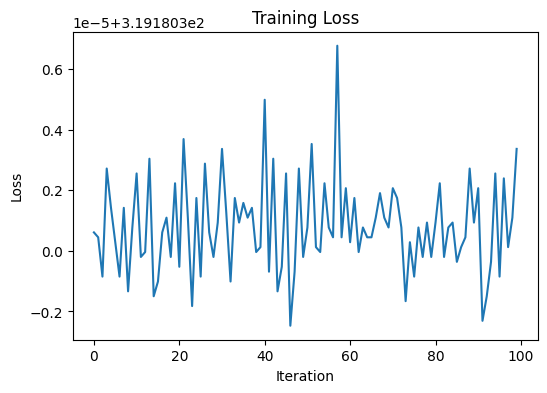

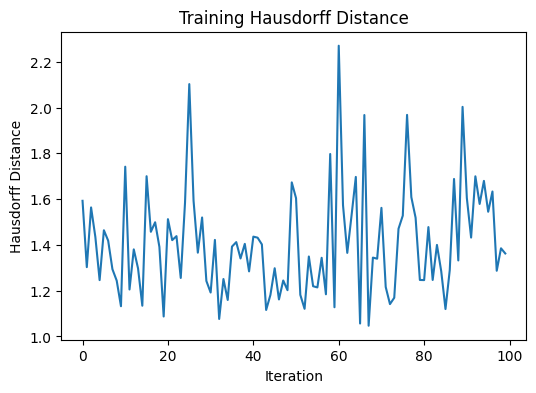

In [25]:
mask = torch.ones(2)

np.random.seed(6)
torch.manual_seed(6)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


All mask:

Epoch 1, Loss: 200.3773
Hausdorff distance: 1.3366
Epoch 2, Loss: 201.6249
Hausdorff distance: 1.2893
Epoch 3, Loss: 197.2480
Hausdorff distance: 1.7315
Epoch 4, Loss: 193.4175
Hausdorff distance: 1.1032
Epoch 5, Loss: 187.0853
Hausdorff distance: 1.6808
Epoch 6, Loss: 196.9826
Hausdorff distance: 1.3582
Epoch 7, Loss: 193.3434
Hausdorff distance: 1.3279
Epoch 8, Loss: 191.4183
Hausdorff distance: 1.4762
Epoch 9, Loss: 191.2645
Hausdorff distance: 1.3921
Epoch 10, Loss: 191.9057
Hausdorff distance: 1.1553
Epoch 11, Loss: 194.4379
Hausdorff distance: 1.5455
Epoch 12, Loss: 186.4770
Hausdorff distance: 0.9328
Epoch 13, Loss: 191.3136
Hausdorff distance: 1.2984
Epoch 14, Loss: 190.6316
Hausdorff distance: 1.5587
Epoch 15, Loss: 190.6910
Hausdorff distance: 1.0982
Epoch 16, Loss: 186.4943
Hausdorff distance: 1.4133
Epoch 17, Loss: 200.5761
Hausdorff distance: 1.2113
Epoch 18, Loss: 195.3009
Hausdorff distance: 1.1352
Epoch 19, Loss: 193.4001
Hausdorff distance: 1.3656
Epoch 20, Loss: 200.6

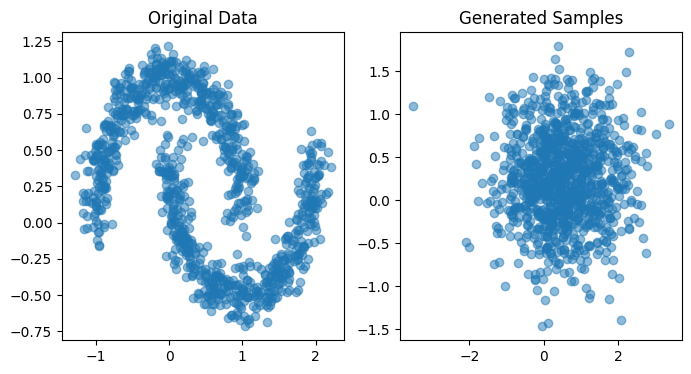

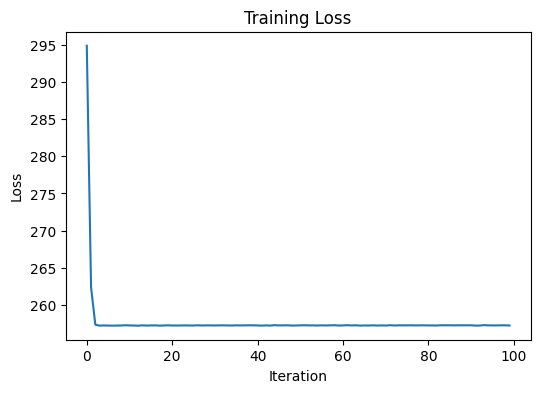

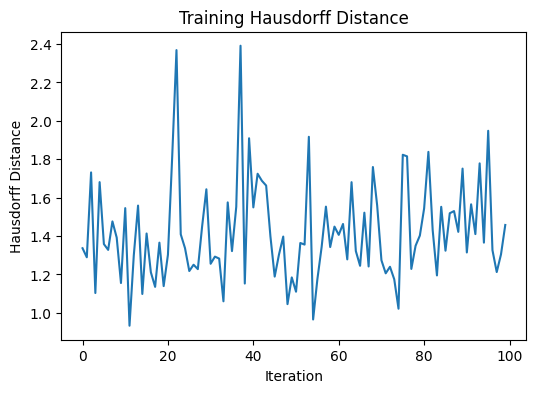

In [26]:
mask = torch.zeros(2)
np.random.seed(6)
torch.manual_seed(6)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()
